In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Import PyTorch
import torch

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [2]:
sionna.phy.config.seed = 41

# Python RNG - use instead of
# import random
# random.randint(0, 10)
print(sionna.phy.config.py_rng.randint(0,10))

# NumPy RNG - use instead of
# import numpy as np
# np.random.randint(0, 10)
print(sionna.phy.config.np_rng.integers(0,10))

# PyTorch RNG - use instead of
# import torch
# torch.randint(0, 10, (1,))
torch_gen = sionna.phy.config.torch_rng()
device = sionna.phy.config.device
print(torch.randint(0, 10, (1,), device=device, generator=torch_gen).item())

6
6
6


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -3.0 | 2.1047e-01 | 1.0000e+00 |      431044 |     2048000 |         2000 |        2000 |         0.8 |reached target block errors
   -2.579 | 2.0073e-01 | 1.0000e+00 |      411092 |     2048000 |         2000 |        2000 |         0.7 |reached target block errors
   -2.158 | 1.9022e-01 | 1.0000e+00 |      389568 |     2048000 |         2000 |        2000 |         0.7 |reached target block errors
   -1.737 | 1.8059e-01 | 1.0000e+00 |      369848 |     2048000 |         2000 |        2000 |         0.7 |reached target block errors
   -1.316 | 1.7085e-01 | 1.0000e+00 |      349905 |     2048000 |         2000 |        2000 |         0.7 |reached target block errors
   -0.895 | 1.6099e-01 | 1.0000e+00 |      329713 |     2048000 |

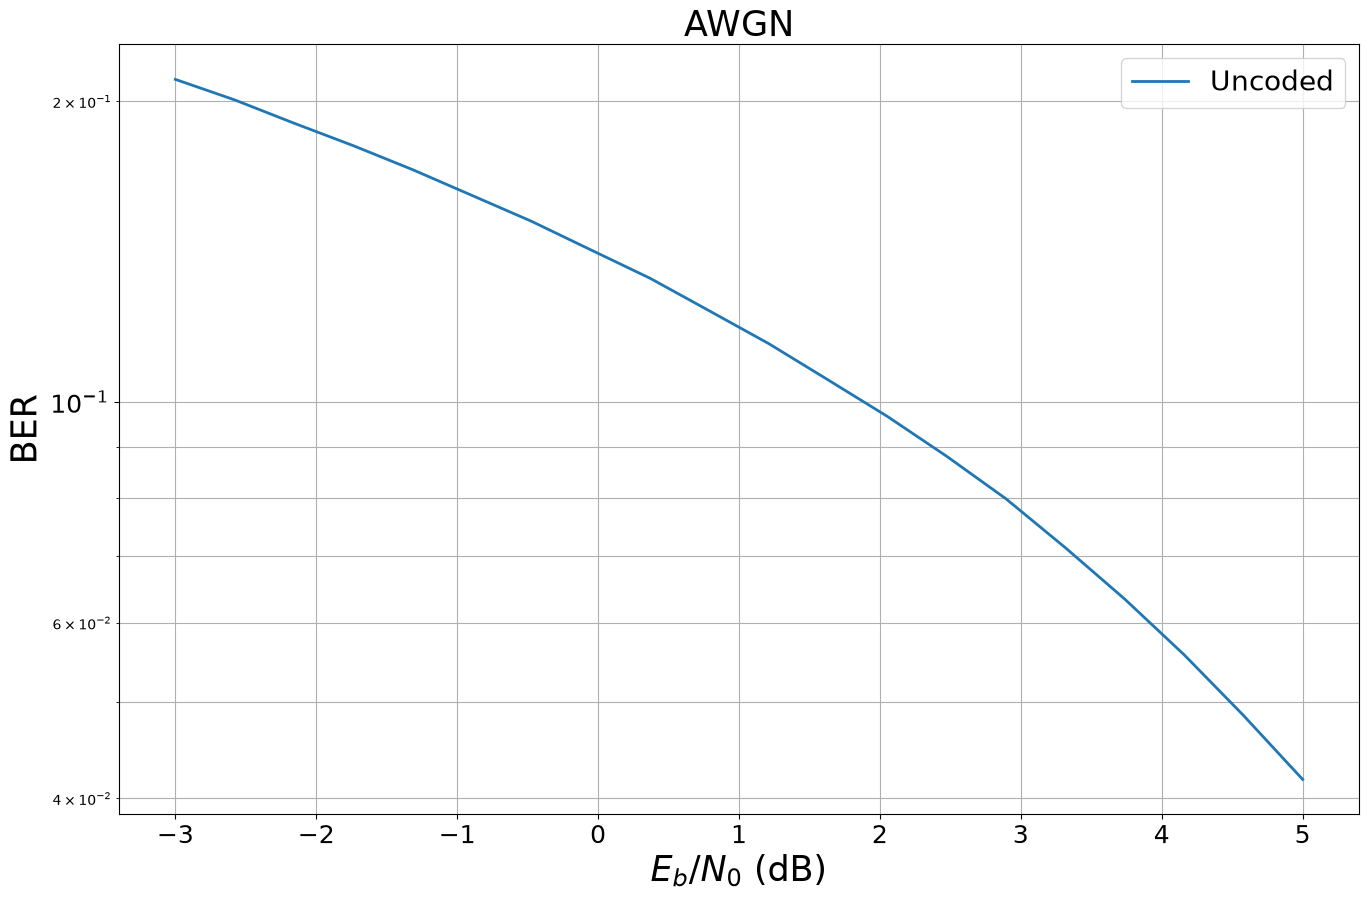

In [5]:
NUM_BITS_PER_SYMBOL=4
BLOCK_LENGTH=1024

class UncodedSystemAWGN(sionna.phy.Block):
    def __init__(self, num_bits_per_symbol, block_length):
        """
        A Sionna Block for uncoded transmission over the AWGN channel

        Parameters
        ----------
        num_bits_per_symbol: int
            The number of bits per constellation symbol, e.g., 4 for QAM16.

        block_length: int
            The number of bits per transmitted message block (will be the codeword length later).

        Input
        -----
        batch_size: int
            The batch_size of the Monte-Carlo simulation.

        ebno_db: float
            The `Eb/No` value (=rate-adjusted SNR) in dB.

        Output
        ------
        (bits, llr):
            Tuple:

        bits: torch.Tensor
            A tensor of shape `[batch_size, block_length] of 0s and 1s
            containing the transmitted information bits.

        llr: torch.Tensor
            A tensor of shape `[batch_size, block_length] containing the
            received log-likelihood-ratio (LLR) values.
        """

        super().__init__() # Must call the block initializer

        # comment each self
        self.num_bits_per_symbol = num_bits_per_symbol
        self.block_length = block_length
        self.constellation = sionna.phy.mapping.Constellation("qam", self.num_bits_per_symbol)
        self.mapper = sionna.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = sionna.phy.mapping.Demapper("app", constellation=self.constellation)
        self.binary_source = sionna.phy.mapping.BinarySource()
        self.awgn_channel = sionna.phy.channel.AWGN()

    # @torch.compile # Enable compilation to speed things up
    def call(self, batch_size, ebno_db):

        # no channel coding used; we set coderate=1.0
        no = sionna.phy.utils.ebnodb2no(ebno_db,
                                num_bits_per_symbol=self.num_bits_per_symbol,
                                coderate=1.0)

        bits = self.binary_source([batch_size, self.block_length]) # Blocklength set to 1024 bits
        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y,no)
        return bits, llr

# instantiate the model
model_uncoded_awgn = UncodedSystemAWGN(num_bits_per_symbol=NUM_BITS_PER_SYMBOL, block_length=BLOCK_LENGTH)

EBN0_DB_MIN = -3.0 # Minimum value of Eb/N0 [dB] for simulations
EBN0_DB_MAX = 5.0 # Maximum value of Eb/N0 [dB] for simulations
BATCH_SIZE = 2000 # How many examples are processed by Sionna in parallel

ber_plots = sionna.phy.utils.PlotBER("AWGN")
ber_plots.simulate(model_uncoded_awgn,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occured
                  legend="Uncoded",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=True);